Fetching data for portfolio: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA']...


/tmp/ipython-input-2631026030.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2020-01-01", end="2024-01-01", progress=False)



--- RISK REPORT (95% Confidence) ---
Portfolio Value: $100,000
1. Historical VaR:  $3,377.24  (-3.38%)
2. Parametric VaR:  $3,323.93  (-3.32%)
3. Monte Carlo VaR: $3,345.00  (-3.35%)


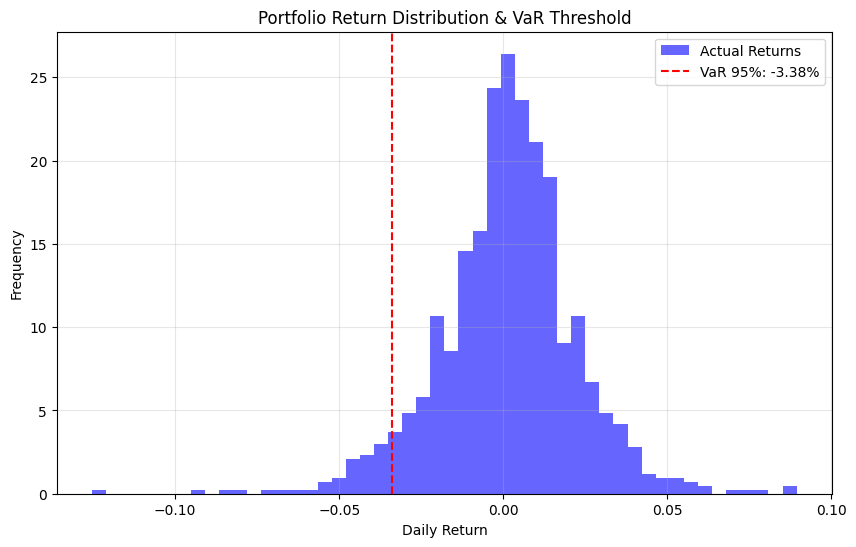

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==========================================
# 1. BUILD THE PORTFOLIO
# ==========================================
tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA']
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2]) # Equal weighting (20% each)
initial_investment = 100000 # $100,000 Portfolio

print(f"Fetching data for portfolio: {tickers}...")
data = yf.download(tickers, start="2020-01-01", end="2024-01-01", progress=False)

# Fix for yfinance MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    data = data['Close']

# Calculate Daily Returns
returns = data.pct_change().dropna()

# Calculate Portfolio Daily Returns (Weighted sum of stock returns)
# We use the dot product (matrix multiplication) for this
port_returns = returns.dot(weights)

# ==========================================
# 2. MODEL A: HISTORICAL VaR (95%)
# Logic: Sort past returns, find the bottom 5%
# ==========================================
conf_level = 0.95
hist_var_percent = np.percentile(port_returns, (1 - conf_level) * 100)
hist_var_dollar = initial_investment * hist_var_percent

# ==========================================
# 3. MODEL B: PARAMETRIC VaR (Normal Dist)
# Logic: Use Mean & Std Dev to calculate the cutoff
# ==========================================
mean_return = port_returns.mean()
std_dev = port_returns.std()

# Use Scipy's 'ppf' (Percent Point Function) to find the inverse of CDF
param_var_percent = norm.ppf(1 - conf_level, mean_return, std_dev)
param_var_dollar = initial_investment * param_var_percent

# ==========================================
# 4. MODEL C: MONTE CARLO VaR
# Logic: Simulate 10,000 tomorrows
# ==========================================
np.random.seed(42) # Ensure results are reproducible
simulations = 10000
simulated_returns = np.random.normal(mean_return, std_dev, simulations)

mc_var_percent = np.percentile(simulated_returns, (1 - conf_level) * 100)
mc_var_dollar = initial_investment * mc_var_percent

# ==========================================
# 5. REPORT & VISUALIZATION
# ==========================================
print(f"\n--- RISK REPORT (95% Confidence) ---")
print(f"Portfolio Value: ${initial_investment:,.0f}")
print(f"1. Historical VaR:  ${abs(hist_var_dollar):,.2f}  ({hist_var_percent*100:.2f}%)")
print(f"2. Parametric VaR:  ${abs(param_var_dollar):,.2f}  ({param_var_percent*100:.2f}%)")
print(f"3. Monte Carlo VaR: ${abs(mc_var_dollar):,.2f}  ({mc_var_percent*100:.2f}%)")

# Visualize the Distribution
plt.figure(figsize=(10, 6))
plt.hist(port_returns, bins=50, density=True, alpha=0.6, color='blue', label='Actual Returns')

# Draw the VaR line (Using Historical for the chart)
plt.axvline(hist_var_percent, color='red', linestyle='--', label=f'VaR 95%: {hist_var_percent*100:.2f}%')

plt.title("Portfolio Return Distribution & VaR Threshold")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- BACKTEST RESULTS ---
Total Trading Days: 955
Number of Breaches: 56
Actual Breach Rate: 5.86%
Expected Breach Rate: 5.00%
STATUS: FAIL (Risk was underestimated)


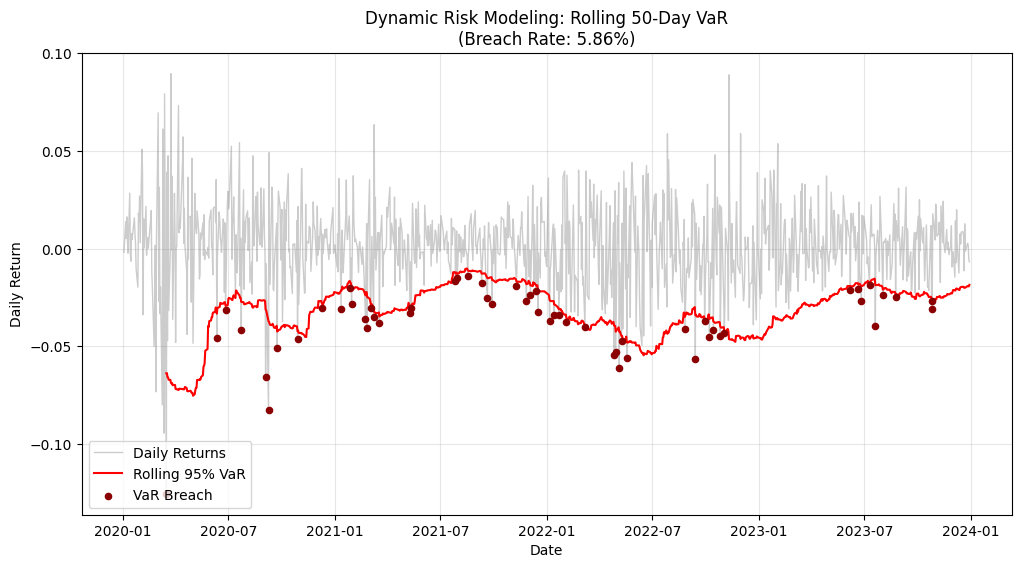

In [2]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==========================================
# 1. SETTINGS
# ==========================================
window = 50  # Look back at the last 50 trading days
conf_level = 0.95

# ==========================================
# 2. CALCULATE ROLLING STATISTICS
# ==========================================
# We need Rolling Mean and Rolling Std Dev to calc VaR dynamically
rolling_mean = port_returns.rolling(window=window).mean()
rolling_std = port_returns.rolling(window=window).std()

# Calculate VaR (The "Red Line")
# Formula: Mean + (Z-Score * StdDev)
# For 95% confidence, Z-Score is approx -1.65
z_score = norm.ppf(1 - conf_level)
rolling_var = rolling_mean + (z_score * rolling_std)

# ==========================================
# 3. IDENTIFY "BREACHES" (Backtesting)
# A "Breach" is when actual loss > predicted VaR
# ==========================================
# If Actual Return < VaR Limit, we failed.
breaches = port_returns[port_returns < rolling_var]
breach_count = len(breaches)
total_days = len(port_returns) - window # Subtract window size (NaNs)
breach_rate = (breach_count / total_days) * 100

print(f"--- BACKTEST RESULTS ---")
print(f"Total Trading Days: {total_days}")
print(f"Number of Breaches: {breach_count}")
print(f"Actual Breach Rate: {breach_rate:.2f}%")
print(f"Expected Breach Rate: {(1-conf_level)*100:.2f}%")
if breach_rate > (1-conf_level)*100:
    print("STATUS: FAIL (Risk was underestimated)")
else:
    print("STATUS: PASS (Model is conservative)")

# ==========================================
# 4. VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 6))

# Plot Actual Returns (Grey)
plt.plot(port_returns.index, port_returns, color='grey', alpha=0.4, label='Daily Returns', linewidth=1)

# Plot The Rolling VaR (Red Line)
plt.plot(rolling_var.index, rolling_var, color='red', label='Rolling 95% VaR', linewidth=1.5)

# Highlight the Breaches (Red Dots)
plt.scatter(breaches.index, breaches, color='darkred', label='VaR Breach', zorder=5, s=20)

plt.title(f"Dynamic Risk Modeling: Rolling 50-Day VaR\n(Breach Rate: {breach_rate:.2f}%)")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()